# RSO-80: Assess the Scheduler CSC configuration time after enabling

**Descripcion**

I was interested in evaluating the time from when the scheduler CSC is enabled, to when the scheduler CSC is configured.

 

The context for this is to evaluate the overall latency of the Rubin ToO system. We have advanced information from the LVK side, and 2/5 of the Rubin steps for observing. 

 

My thought would be to evaluate this over the entire commissioning period, OR over a period of time since we have deployed any improvements to minimize the configure time.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from lsst.summit.utils.efdUtils import (
    getEfdData,
    getDayObsEndTime,
    getDayObsForTime,
    getDayObsStartTime,
    makeEfdClient,
)
from astropy.time import Time

In [2]:
# Initialize an EFD client
efd_client = makeEfdClient()

In [3]:
# Observation time
start_time = Time("2025-10-01T00:00:00Z", scale="utc")
end_time = Time("2026-02-01T23:59:00Z", scale="utc")

## ************************

In [4]:
# Disable
df_disable = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_disable",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [5]:
df_disable['timestamp'] = df_disable.index
df_disable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2025-10-04 23:07:02.494596+00:00,1.759619e+09,Script:215124,1.759619e+09,93359,0,9c0ea436,422260619,1.759619e+09,2,2025-10-04 23:07:02.494596+00:00
2025-10-05 22:49:09.129696+00:00,1.759705e+09,Script:215641,1.759705e+09,385106,0,9c0ea436,422260619,1.759705e+09,2,2025-10-05 22:49:09.129696+00:00
2025-10-06 23:24:37.025768+00:00,1.759793e+09,Script:216160,1.759793e+09,678017,0,9c0ea436,422260619,1.759793e+09,2,2025-10-06 23:24:37.025768+00:00
2025-10-07 12:54:34.164027+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,9c0ea436,343799766,1.759842e+09,2,2025-10-07 12:54:34.164027+00:00
2025-10-07 12:54:50.892718+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,9c0ea436,344236332,1.759842e+09,3,2025-10-07 12:54:50.892718+00:00
...,...,...,...,...,...,...,...,...,...,...
2026-01-29 13:13:35.737650+00:00,1.769692e+09,Script:117415,1.769692e+09,4149553,0,9c0ea436,293908717,1.769692e+09,3,2026-01-29 13:13:35.737650+00:00
2026-01-29 13:13:50.662412+00:00,1.769692e+09,Script:117415,1.769692e+09,4149553,0,9c0ea436,390819423,1.769692e+09,1,2026-01-29 13:13:50.662412+00:00
2026-01-30 19:38:12.701543+00:00,1.769802e+09,Script:100097,1.769802e+09,36367,0,9c0ea436,326174075,1.769802e+09,1,2026-01-30 19:38:12.701543+00:00
2026-01-30 23:44:54.085399+00:00,1.769817e+09,Script:200686,1.769817e+09,392783,0,9c0ea436,326174075,1.769817e+09,2,2026-01-30 23:44:54.085399+00:00


In [6]:
# Enable
df_enable = getEfdData(
            client=efd_client,
            topic="lsst.sal.Scheduler.command_enable",
            columns=["*"],
            begin=start_time,
            end=end_time,
)

In [7]:
df_enable['timestamp'] = df_enable.index
df_enable

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2025-10-04 23:07:28.184766+00:00,1.759619e+09,Script:215124,1.759619e+09,93359,0,4123e633,608791694,1.759619e+09,2,2025-10-04 23:07:28.184766+00:00
2025-10-05 22:49:34.658968+00:00,1.759705e+09,Script:215641,1.759705e+09,385106,0,4123e633,608791694,1.759705e+09,2,2025-10-05 22:49:34.658968+00:00
2025-10-06 23:25:03.057211+00:00,1.759793e+09,Script:216160,1.759793e+09,678017,0,4123e633,608791694,1.759793e+09,2,2025-10-06 23:25:03.057211+00:00
2025-10-08 12:49:42.740417+00:00,1.759928e+09,Script:200019,1.759928e+09,5886,0,4123e633,476961495,1.759928e+09,2,2025-10-08 12:49:42.740417+00:00
2025-10-09 23:13:52.234607+00:00,1.760052e+09,Script:200009,1.760052e+09,3305,0,4123e633,476961495,1.760052e+09,2,2025-10-09 23:13:52.234607+00:00
...,...,...,...,...,...,...,...,...,...,...
2026-01-30 19:43:51.334118+00:00,1.769802e+09,Script:100097,1.769802e+09,36367,0,4123e633,476961495,1.769802e+09,1,2026-01-30 19:43:51.334118+00:00
2026-01-30 23:45:27.303945+00:00,1.769817e+09,Script:200686,1.769817e+09,392783,0,4123e633,476961495,1.769817e+09,2,2026-01-30 23:45:27.303945+00:00
2026-01-31 08:54:04.712976+00:00,1.769850e+09,kkelkar@summit-lsp.lsst.codes,1.769850e+09,12,0,4123e633,533066184,1.769850e+09,2,2026-01-31 08:54:04.712976+00:00
2026-02-01 00:46:51.108578+00:00,1.769907e+09,Script:201348,1.769907e+09,771043,0,4123e633,476961495,1.769907e+09,2,2026-02-01 00:46:51.108578+00:00


In [8]:
# Exit Control
df_exitControl = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_exitControl",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [9]:
df_exitControl['timestamp'] = df_exitControl.index
df_exitControl

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2025-10-07 12:54:44.761810+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,939a5bee,733799081,1.759842e+09,2,2025-10-07 12:54:44.761810+00:00
2025-10-07 12:55:01.488538+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,939a5bee,634701742,1.759842e+09,3,2025-10-07 12:55:01.488538+00:00
2025-10-07 12:55:22.206188+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,939a5bee,640044094,1.759842e+09,1,2025-10-07 12:55:22.206188+00:00
2025-10-09 12:31:05.323868+00:00,1.760013e+09,Script:100006,1.760013e+09,2966,0,939a5bee,664435174,1.760013e+09,2,2025-10-09 12:31:05.323868+00:00
2025-10-09 12:31:10.392839+00:00,1.760013e+09,Script:100006,1.760013e+09,2966,0,939a5bee,616039665,1.760013e+09,3,2025-10-09 12:31:10.392839+00:00
2025-10-09 12:31:14.400084+00:00,1.760013e+09,Script:100006,1.760013e+09,2966,0,939a5bee,661872924,1.760013e+09,1,2025-10-09 12:31:14.400084+00:00
2025-10-13 20:05:48.318851+00:00,1.760386e+09,Script:201662,1.760386e+09,1022336,0,939a5bee,597761581,1.760386e+09,2,2025-10-13 20:05:48.318851+00:00
2025-10-13 20:05:49.285417+00:00,1.760386e+09,Script:201662,1.760386e+09,1022336,0,939a5bee,572278436,1.760386e+09,3,2025-10-13 20:05:49.285417+00:00
2025-10-13 21:12:37.405535+00:00,1.760390e+09,Script:100040,1.760390e+09,20797,0,939a5bee,597761581,1.760390e+09,1,2025-10-13 21:12:37.405535+00:00
2025-10-29 20:37:51.386037+00:00,1.761770e+09,Script:103566,1.761770e+09,2207443,0,939a5bee,597761581,1.761770e+09,1,2025-10-29 20:37:51.386037+00:00


In [10]:
# setLogLevel
df_setLogLevel = getEfdData(
                 client=efd_client,
                 topic="lsst.sal.Scheduler.command_setLogLevel",
                 columns=["*"],
                 begin=start_time,
                 end=end_time,
)

In [11]:
df_setLogLevel['timestamp'] = df_setLogLevel.index
df_setLogLevel

,level,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,subsystem,timestamp
2025-11-18 19:10:05.241369+00:00,10,1.763493e+09,tribeiro@summit-lsp.lsst.codes,1.763493e+09,12,0,af036b61,1551954086,1.763493e+09,1,,2025-11-18 19:10:05.241369+00:00
2025-11-18 19:10:09.674851+00:00,20,1.763493e+09,tribeiro@summit-lsp.lsst.codes,1.763493e+09,12,0,af036b61,1551954087,1.763493e+09,1,,2025-11-18 19:10:09.674851+00:00
2026-01-05 05:34:02.669946+00:00,10,1.767591e+09,tribeiro@summit-lsp.lsst.codes,1.767591e+09,12,0,af036b61,1591807264,1.767591e+09,1,,2026-01-05 05:34:02.669946+00:00
2026-01-05 05:34:09.190779+00:00,20,1.767591e+09,tribeiro@summit-lsp.lsst.codes,1.767591e+09,12,0,af036b61,1591807265,1.767591e+09,1,,2026-01-05 05:34:09.190779+00:00
2026-01-05 05:38:37.231354+00:00,10,1.767592e+09,tribeiro@summit-lsp.lsst.codes,1.767592e+09,12,0,af036b61,1591807266,1.767592e+09,1,,2026-01-05 05:38:37.231354+00:00
2026-01-05 05:41:39.946603+00:00,20,1.767592e+09,tribeiro@summit-lsp.lsst.codes,1.767592e+09,12,0,af036b61,1591807267,1.767592e+09,1,,2026-01-05 05:41:39.946603+00:00
2026-01-05 05:48:22.689015+00:00,10,1.767592e+09,tribeiro@summit-lsp.lsst.codes,1.767592e+09,12,0,af036b61,1591807268,1.767592e+09,1,,2026-01-05 05:48:22.689015+00:00
2026-01-05 05:48:25.525207+00:00,20,1.767592e+09,tribeiro@summit-lsp.lsst.codes,1.767592e+09,12,0,af036b61,1591807269,1.767592e+09,1,,2026-01-05 05:48:25.525207+00:00


In [12]:
# standby
df_standby = getEfdData(
             client=efd_client,
             topic="lsst.sal.Scheduler.command_standby",
             columns=["*"],
             begin=start_time,
             end=end_time,
)

In [13]:
df_standby['timestamp'] = df_standby.index
df_standby

,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2025-10-04 23:07:08.047424+00:00,1.759619e+09,Script:215124,1.759619e+09,93359,0,cd1b64f4,1639255097,1.759619e+09,2,2025-10-04 23:07:08.047424+00:00
2025-10-05 22:49:14.687215+00:00,1.759705e+09,Script:215641,1.759705e+09,385106,0,cd1b64f4,1639255097,1.759705e+09,2,2025-10-05 22:49:14.687215+00:00
2025-10-06 23:24:42.575004+00:00,1.759793e+09,Script:216160,1.759793e+09,678017,0,cd1b64f4,1639255097,1.759793e+09,2,2025-10-06 23:24:42.575004+00:00
2025-10-07 12:54:39.704697+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,cd1b64f4,1559172044,1.759842e+09,2,2025-10-07 12:54:39.704697+00:00
2025-10-07 12:54:56.432570+00:00,1.759842e+09,Script:112073,1.759842e+09,3102537,0,cd1b64f4,1561477980,1.759842e+09,3,2025-10-07 12:54:56.432570+00:00
...,...,...,...,...,...,...,...,...,...,...
2026-01-30 19:38:18.278294+00:00,1.769802e+09,Script:100097,1.769802e+09,36367,0,cd1b64f4,1616103400,1.769802e+09,1,2026-01-30 19:38:18.278294+00:00
2026-01-30 23:44:59.637301+00:00,1.769817e+09,Script:200686,1.769817e+09,392783,0,cd1b64f4,1616103400,1.769817e+09,2,2026-01-30 23:44:59.637301+00:00
2026-01-31 08:53:18.648376+00:00,1.769850e+09,kkelkar@summit-lsp.lsst.codes,1.769850e+09,12,0,cd1b64f4,1741405583,1.769850e+09,2,2026-01-31 08:53:18.648376+00:00
2026-02-01 00:46:21.799568+00:00,1.769907e+09,Script:201348,1.769907e+09,771043,0,cd1b64f4,1616103400,1.769907e+09,2,2026-02-01 00:46:21.799568+00:00


In [14]:
# Start
df_start = getEfdData(
           client=efd_client,
           topic="lsst.sal.Scheduler.command_start",
           columns=["*"],
           begin=start_time,
           end=end_time,
)

In [15]:
df_start['timestamp'] = df_start.index
df_start

,configurationOverride,private_efdStamp,private_identity,private_kafkaStamp,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,salIndex,timestamp
2025-10-04 23:07:09.100593+00:00,auxtel_fbs_spec_flex_survey.yaml,1.759619e+09,Script:215124,1.759619e+09,93359,0,52da5621,1698289930,1.759619e+09,2,2025-10-04 23:07:09.100593+00:00
2025-10-05 22:49:15.731438+00:00,auxtel_fbs_spec_flex_survey.yaml,1.759705e+09,Script:215641,1.759705e+09,385106,0,52da5621,1698289930,1.759705e+09,2,2025-10-05 22:49:15.731438+00:00
2025-10-06 23:24:43.620830+00:00,auxtel_fbs_spec_flex_survey.yaml,1.759793e+09,Script:216160,1.759793e+09,678017,0,52da5621,1698289930,1.759793e+09,2,2025-10-06 23:24:43.620830+00:00
2025-10-08 12:49:22.560453+00:00,auxtel_fbs_spec_flex_survey.yaml,1.759928e+09,Script:200019,1.759928e+09,5886,0,52da5621,1851544648,1.759928e+09,2,2025-10-08 12:49:22.560453+00:00
2025-10-09 23:13:33.183855+00:00,auxtel_fbs_spec_flex_survey.yaml,1.760052e+09,Script:200009,1.760052e+09,3305,0,52da5621,1851544648,1.760052e+09,2,2025-10-09 23:13:33.183855+00:00
...,...,...,...,...,...,...,...,...,...,...,...
2026-01-30 19:38:19.355355+00:00,fbs_config_lsst_survey_block_419.yaml,1.769802e+09,Script:100097,1.769802e+09,36367,0,52da5621,1851544648,1.769802e+09,1,2026-01-30 19:38:19.355355+00:00
2026-01-30 23:45:00.712006+00:00,auxtel_fbs_spec_flex_survey.yaml,1.769817e+09,Script:200686,1.769817e+09,392783,0,52da5621,1851544648,1.769817e+09,2,2026-01-30 23:45:00.712006+00:00
2026-01-31 08:53:33.400658+00:00,,1.769850e+09,kkelkar@summit-lsp.lsst.codes,1.769850e+09,12,0,52da5621,1757273707,1.769850e+09,2,2026-01-31 08:53:33.400658+00:00
2026-02-01 00:46:22.871070+00:00,auxtel_fbs_spec_flex_survey.yaml,1.769907e+09,Script:201348,1.769907e+09,771043,0,52da5621,1851544648,1.769907e+09,2,2026-02-01 00:46:22.871070+00:00


## latencies

In [ ]:
'''
for df in [df_disable, df_enable, df_standby, df_start]:
    mask = df["private_identity"].str.startswith("Script:")
    df.loc[mask, "script_id"] = (
        df.loc[mask, "private_identity"]
        .str.replace("Script:", "", regex=False)
        .astype(int)
    )
'''    

In [18]:
"""
Some private_identity entries do not have the format script_*****, where ***** is a number. 
Instead, a user's email address appears. So, to analyze them, I am separating those with the format 
Script_**** and those that contain a user's name. 
"""
def split_scripts_and_non_scripts(df):
    df["private_identity"] = df["private_identity"].astype(str).str.strip()

    mask_script = df["private_identity"].str.fullmatch(r"Script:\d+")

    print(mask_script.value_counts())

    # scripts ok
    df_scripts = df.loc[mask_script].copy()
    df_scripts["script_id"] = (
        df_scripts["private_identity"]
        .str.replace("Script:", "", regex=False)
        .astype(int)
    )

    # no scripts - email address
    df_non_scripts = df.loc[~mask_script].copy()

    return df_scripts, df_non_scripts

In [20]:
df_disable, df_disable_non_scripts = split_scripts_and_non_scripts(df_disable)
df_enable,  df_enable_non_scripts  = split_scripts_and_non_scripts(df_enable)
df_standby, df_standby_non_scripts = split_scripts_and_non_scripts(df_standby)
df_start,   df_start_non_scripts   = split_scripts_and_non_scripts(df_start)

private_identity
True     336
False     22
Name: count, dtype: int64
private_identity
True     373
False     24
Name: count, dtype: int64
private_identity
True     352
False     40
Name: count, dtype: int64
private_identity
True     397
False     39
Name: count, dtype: int64


In [22]:
df_disable_lat = df_disable[['script_id', 'timestamp']]
df_enable_lat  = df_enable[['script_id', 'timestamp']]
df_standby_lat = df_standby[['script_id', 'timestamp']]
df_start_lat    = df_start[['script_id', 'timestamp']]

In [24]:
# Rename column of timestamp
df_disable_lat = df_disable_lat.rename(columns={'timestamp': 'ts_disable'})
df_enable_lat  = df_enable_lat.rename(columns={'timestamp': 'ts_enable'})
df_standby_lat = df_standby_lat.rename(columns={'timestamp': 'ts_standby'})
df_start_lat    = df_start_lat.rename(columns={'timestamp': 'ts_start'})

In [25]:
# Partial Latencies 
df_latencies = (
    df_disable_lat
    .merge(df_enable_lat,  on='script_id', how='inner')
    .merge(df_standby_lat, on='script_id', how='inner')
    .merge(df_start_lat,   on='script_id', how='inner')
)

In [26]:
df_latencies['lat_disable_enable_s'] = (
    df_latencies['ts_enable'] - df_latencies['ts_disable']
).dt.total_seconds() # * 1000

In [27]:
df_latencies['lat_enable_standby_s'] = (
    df_latencies['ts_standby'] - df_latencies['ts_enable']
).dt.total_seconds() # * 1000

In [28]:
df_latencies['lat_standby_start_s'] = (
    df_latencies['ts_start'] - df_latencies['ts_standby']
).dt.total_seconds()

In [29]:
df_latencies['lat_start2disable_s'] = (
    df_latencies['ts_start'] - df_latencies['ts_disable']
).dt.total_seconds() # * 1000

In [30]:
df_latencies

,script_id,ts_disable,ts_enable,ts_standby,ts_start,lat_disable_enable_s,lat_enable_standby_s,lat_standby_start_s,lat_start2disable_s
0,215124,2025-10-04 23:07:02.494596+00:00,2025-10-04 23:07:28.184766+00:00,2025-10-04 23:07:08.047424+00:00,2025-10-04 23:07:09.100593+00:00,2.569017e+01,-2.013734e+01,1.053169e+00,6.605997e+00
1,215641,2025-10-05 22:49:09.129696+00:00,2025-10-05 22:49:34.658968+00:00,2025-10-05 22:49:14.687215+00:00,2025-10-05 22:49:15.731438+00:00,2.552927e+01,-1.997175e+01,1.044223e+00,6.601742e+00
2,216160,2025-10-06 23:24:37.025768+00:00,2025-10-06 23:25:03.057211+00:00,2025-10-06 23:24:42.575004+00:00,2025-10-06 23:24:43.620830+00:00,2.603144e+01,-2.048221e+01,1.045826e+00,6.595062e+00
3,112073,2025-10-07 12:54:34.164027+00:00,2026-01-11 00:37:43.405530+00:00,2025-10-07 12:54:39.704697+00:00,2026-01-11 00:32:40.893540+00:00,8.250189e+06,-8.250184e+06,8.249881e+06,8.249887e+06
4,112073,2025-10-07 12:54:34.164027+00:00,2026-01-11 00:37:43.405530+00:00,2025-10-07 12:54:56.432570+00:00,2026-01-11 00:32:40.893540+00:00,8.250189e+06,-8.250167e+06,8.249864e+06,8.249887e+06
...,...,...,...,...,...,...,...,...,...
326,222476,2026-01-28 23:46:06.514417+00:00,2026-01-28 23:46:42.049041+00:00,2026-01-28 23:46:12.096475+00:00,2026-01-28 23:46:13.142413+00:00,3.553462e+01,-2.995257e+01,1.045938e+00,6.627996e+00
327,117051,2026-01-29 00:45:26.041254+00:00,2026-01-29 00:51:14.520309+00:00,2026-01-29 00:45:31.653726+00:00,2026-01-29 00:45:32.700155+00:00,3.484791e+02,-3.428666e+02,1.046429e+00,6.658901e+00
328,100097,2026-01-30 19:38:12.701543+00:00,2026-01-30 19:43:51.334118+00:00,2026-01-30 19:38:18.278294+00:00,2026-01-30 19:38:19.355355+00:00,3.386326e+02,-3.330558e+02,1.077061e+00,6.653812e+00
329,200686,2026-01-30 23:44:54.085399+00:00,2026-01-30 23:45:27.303945+00:00,2026-01-30 23:44:59.637301+00:00,2026-01-30 23:45:00.712006+00:00,3.321855e+01,-2.766664e+01,1.074705e+00,6.626607e+00


# Negative times (check)

In [31]:
df_negative = df_latencies[df_latencies["lat_disable_enable_s"] < 0]
len(df_negative)


6

In [32]:
len(df_latencies)

331

I don't understand why some latencies between disable and enable are negative. It's true that there aren't many, but I don't understand why.

### Plots

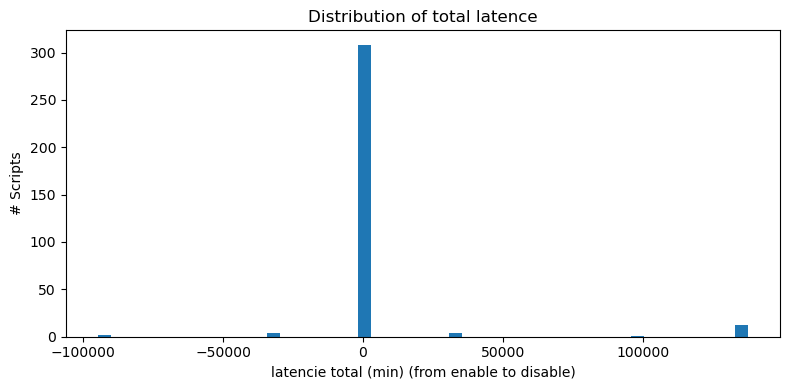

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(df_latencies['lat_disable_enable_s'] / 60.0, bins=50)
plt.xlabel('latencie total (min) (from enable to disable)')
plt.ylabel('# Scripts')
plt.title('Distribution of total latence')
plt.tight_layout()
plt.show()

It also appears that there are some excessively long latencies. Although there are not many. Each case could be looked at individually.

In [34]:
df_latencies['lat_disable_enable_s'].describe(percentiles=[0.5, 0.95, 0.99])


count    3.310000e+02
mean     2.827417e+05
std      1.672720e+06
min     -5.677208e+06
50%      1.144688e+02
95%      1.027479e+06
99%      8.250184e+06
max      8.250189e+06
Name: lat_disable_enable_s, dtype: float64

I believe these statistics are skewed by the few anomalous data points that exist.

In [35]:
# We group by observation night
df_latencies['date'] = df_latencies['ts_enable'].dt.date

mean_by_night = df_latencies.groupby('date')['lat_disable_enable_s'].mean().reset_index()
print(mean_by_night)


           date  lat_disable_enable_s
0    2025-10-04             25.690170
1    2025-10-05             25.529272
2    2025-10-06             26.031443
3    2025-10-10             27.804444
4    2025-10-11             32.624059
..          ...                   ...
109  2026-01-27             36.663062
110  2026-01-28            238.003631
111  2026-01-29            348.479055
112  2026-01-30            185.925560
113  2026-02-01             34.879935

[114 rows x 2 columns]


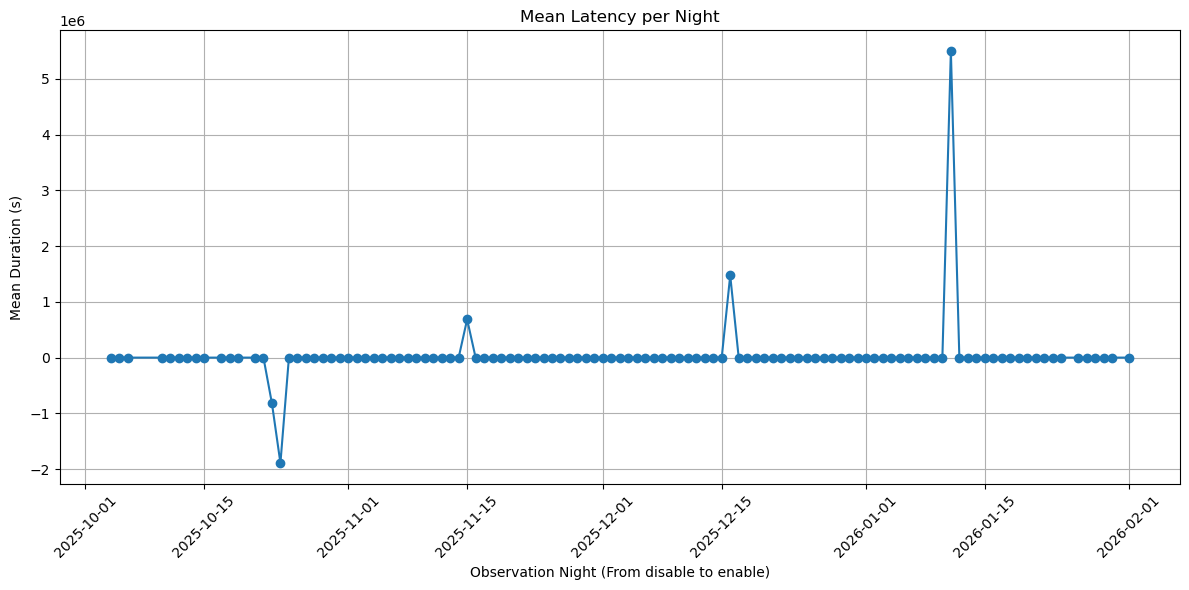

In [36]:
mean_by_night['date'] = pd.to_datetime(mean_by_night['date'])

plt.figure(figsize=(12,6))
plt.plot(mean_by_night['date'], mean_by_night['lat_disable_enable_s'], marker='o')
plt.xlabel('Observation Night (From disable to enable)')
plt.ylabel('Mean Duration (s)')
plt.title('Mean Latency per Night')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In this plot, it is easy to see that there are some nights where the average latency skyrockets, most likely due to a script.

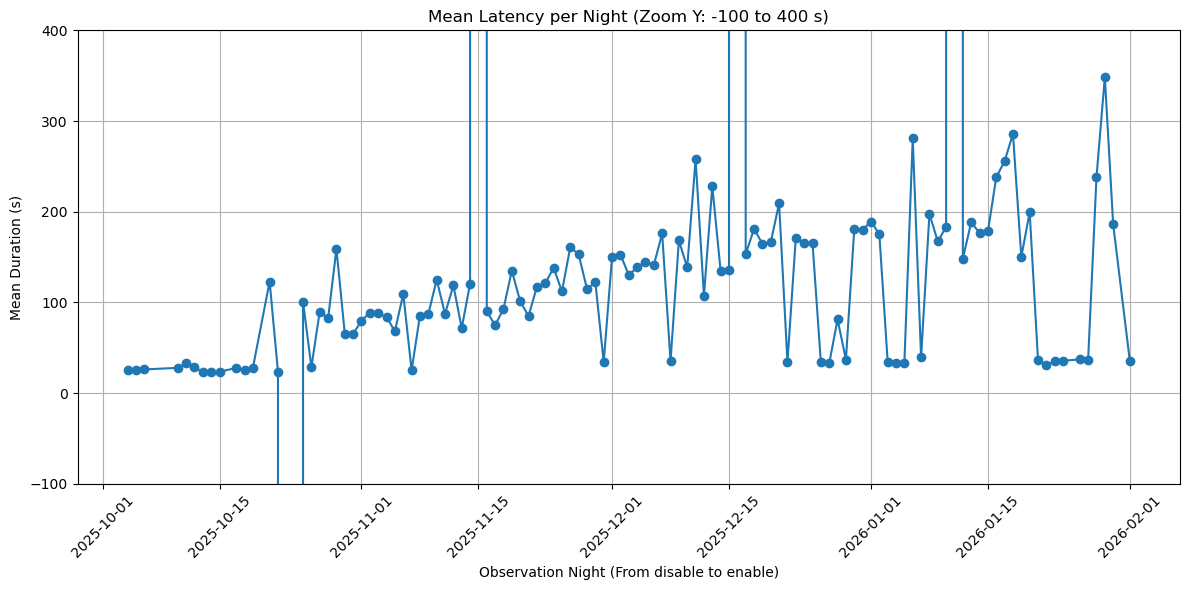

In [44]:
mean_by_night['date'] = pd.to_datetime(mean_by_night['date'])

plt.figure(figsize=(12,6))
plt.plot(mean_by_night['date'],
         mean_by_night['lat_disable_enable_s'],
         marker='o')

plt.xlabel('Observation Night (From disable to enable)')
plt.ylabel('Mean Duration (s)')
plt.title('Mean Latency per Night (Zoom Y: -100 to 400 s)')
plt.ylim(-100, 400) 
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_12389/4148621978.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


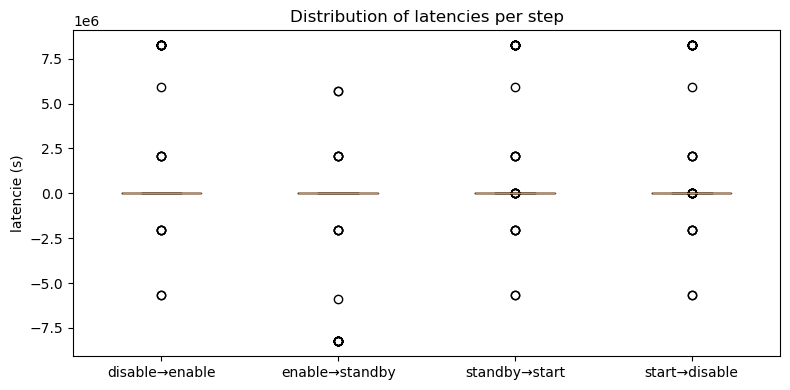

In [38]:
plt.figure(figsize=(8, 4))

plt.boxplot([
    df_latencies['lat_disable_enable_s'],
    df_latencies['lat_enable_standby_s'],
    df_latencies['lat_standby_start_s'],
    df_latencies['lat_start2disable_s'],
], labels=[
    'disable→enable',
    'enable→standby',
    'standby→start',
    'start→disable'
])

plt.ylabel('latencie (s)')
plt.title('Distribution of latencies per step')
plt.tight_layout()
plt.show()

# MTCamara

In [45]:
# MTCamare observational times
df_mtcamara = getEfdData(
            client=efd_client,
            topic="lsst.sal.MTCamera.logevent_endOfImageTelemetry",
            columns=["*"],
            begin=start_time,
            end=end_time,
)

In [46]:
df_mtcamara['timestamp'] = df_mtcamara.index
df_mtcamara['tsDateObs'] = df_mtcamara.index
df_mtcamara

,additionalKeys,additionalValues,darkTime,emulatedImage,exposureTime,imageController,imageDate,imageIndex,imageName,imageNumber,...,private_origin,private_rcvStamp,private_revCode,private_seqNum,private_sndStamp,timestampAcquisitionStart,timestampDateEnd,timestampDateObs,timestamp,tsDateObs
2025-10-14 19:23:42.716950+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2025-10-14T19\:24\:14.164:DARK:0:0:0.0:To...,5.016837,,5.0,C,20251014,1,MC_C_20251014_000011,11,...,1922801208,0,c056116d,144953,1.760470e+09,1.760470e+09,1.760470e+09,1.760470e+09,2025-10-14 19:23:42.716950+00:00,2025-10-14 19:23:42.716950+00:00
2025-10-14 19:26:13.680783+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2025-10-14T19\:26\:45.100:DARK:0:0:0.0:To...,5.015264,,5.0,C,20251014,1,MC_C_20251014_000012,12,...,1922801208,0,c056116d,146491,1.760470e+09,1.760470e+09,1.760470e+09,1.760470e+09,2025-10-14 19:26:13.680783+00:00,2025-10-14 19:26:13.680783+00:00
2025-10-14 19:42:46.261108+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2025-10-14T19\:43\:17.668:DARK:0:0:0.0:To...,5.014948,,5.0,C,20251014,1,MC_C_20251014_000014,14,...,1922801208,0,c056116d,156268,1.760471e+09,1.760471e+09,1.760471e+09,1.760471e+09,2025-10-14 19:42:46.261108+00:00,2025-10-14 19:42:46.261108+00:00
2025-10-15 18:32:07.831610+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2025-10-15T18\:32\:38.798:DARK:0:0:0.0:To...,5.016002,,5.0,C,20251015,1,MC_C_20251015_000022,22,...,544243801,0,c056116d,13810,1.760553e+09,1.760553e+09,1.760553e+09,1.760553e+09,2025-10-15 18:32:07.831610+00:00,2025-10-15 18:32:07.831610+00:00
2025-10-15 18:32:16.666416+00:00,imageType:groupId:testType:stutterRows:stutter...,DARK:2025-10-15T18\:32\:38.798:DARK:0:0:0.0:To...,5.017139,,5.0,C,20251015,1,MC_C_20251015_000023,23,...,544243801,0,c056116d,14003,1.760553e+09,1.760553e+09,1.760553e+09,1.760553e+09,2025-10-15 18:32:16.666416+00:00,2025-10-15 18:32:16.666416+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-29 06:17:07.167728+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-29T06\:14\:26.238#2:ACQ:0:0:0.0:IN...,30.931824,,30.0,O,20260128,1,MC_O_20260128_000339,339,...,-1105720044,0,c056116d,1415560,1.769667e+09,1.769667e+09,1.769667e+09,1.769667e+09,2026-01-29 06:17:07.167728+00:00,2026-01-29 06:17:07.167728+00:00
2026-01-29 06:17:41.453614+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-29T06\:14\:26.238:ACQ:0:0:0.0:INFO...,30.930133,,30.0,O,20260128,1,MC_O_20260128_000340,340,...,-1105720044,0,c056116d,1416001,1.769667e+09,1.769667e+09,1.769667e+09,1.769667e+09,2026-01-29 06:17:41.453614+00:00,2026-01-29 06:17:41.453614+00:00
2026-01-29 06:18:47.845529+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-29T06\:14\:26.238#3:ACQ:0:0:0.0:IN...,30.929736,,30.0,O,20260128,1,MC_O_20260128_000341,341,...,-1105720044,0,c056116d,1416870,1.769668e+09,1.769668e+09,1.769668e+09,1.769668e+09,2026-01-29 06:18:47.845529+00:00,2026-01-29 06:18:47.845529+00:00
2026-01-29 06:19:22.324750+00:00,imageType:groupId:testType:stutterRows:stutter...,ACQ:2026-01-29T06\:14\:26.238:ACQ:0:0:0.0:INFO...,30.931890,,30.0,O,20260128,1,MC_O_20260128_000342,342,...,-1105720044,0,c056116d,1417419,1.769668e+09,1.769668e+09,1.769668e+09,1.769668e+09,2026-01-29 06:19:22.324750+00:00,2026-01-29 06:19:22.324750+00:00


For each script execution, the latency between the time the script was enabled (`ts_enable`) and the next camera data acquisition (`tsDataObs`) that occurred after that enable time.

For every row in `df_latencies`, we search in `df_mtcamara` for the closest `tsDataObs` strictly greater than ts_enable.


In [47]:
# Sort both DataFrames by time
df_latencies = df_latencies.sort_values("ts_enable").reset_index(drop=True)
df_mtcamara = df_mtcamara.sort_values("tsDateObs").reset_index(drop=True)

In [48]:
df_latencies = pd.merge_asof(
    df_latencies,
    df_mtcamara['tsDateObs'],
    left_on="ts_enable",
    right_on="tsDateObs",
    direction="forward",   # ensures tsDataObs > ts_enable
    allow_exact_matches=False
)

In [49]:
#Compute the latency in seconds:
df_latencies["latency_camara"] = (
    df_latencies['tsDateObs'] - df_latencies['ts_enable']
).dt.total_seconds()

In [50]:
df_latencies

,script_id,ts_disable,ts_enable,ts_standby,ts_start,lat_disable_enable_s,lat_enable_standby_s,lat_standby_start_s,lat_start2disable_s,date,tsDateObs,latency_camara
0,215124,2025-10-04 23:07:02.494596+00:00,2025-10-04 23:07:28.184766+00:00,2025-10-04 23:07:08.047424+00:00,2025-10-04 23:07:09.100593+00:00,25.690170,-20.137342,1.053169,6.605997,2025-10-04,2025-10-14 19:23:42.716950+00:00,850574.532184
1,215641,2025-10-05 22:49:09.129696+00:00,2025-10-05 22:49:34.658968+00:00,2025-10-05 22:49:14.687215+00:00,2025-10-05 22:49:15.731438+00:00,25.529272,-19.971753,1.044223,6.601742,2025-10-05,2025-10-14 19:23:42.716950+00:00,765248.057982
2,216160,2025-10-06 23:24:37.025768+00:00,2025-10-06 23:25:03.057211+00:00,2025-10-06 23:24:42.575004+00:00,2025-10-06 23:24:43.620830+00:00,26.031443,-20.482207,1.045826,6.595062,2025-10-06,2025-10-14 19:23:42.716950+00:00,676719.659739
3,200549,2025-10-10 22:56:50.392178+00:00,2025-10-10 22:57:18.196622+00:00,2025-10-10 22:56:55.947452+00:00,2025-10-10 22:56:56.982832+00:00,27.804444,-22.249170,1.035380,6.590654,2025-10-10,2025-10-14 19:23:42.716950+00:00,332784.520328
4,201073,2025-10-11 23:33:30.845394+00:00,2025-10-11 23:34:03.469453+00:00,2025-10-11 23:33:36.416571+00:00,2025-10-11 23:33:37.467511+00:00,32.624059,-27.052882,1.050940,6.622117,2025-10-11,2025-10-14 19:23:42.716950+00:00,244179.247497
...,...,...,...,...,...,...,...,...,...,...,...,...
326,222476,2026-01-28 23:46:06.514417+00:00,2026-01-28 23:46:42.049041+00:00,2026-01-28 23:46:12.096475+00:00,2026-01-28 23:46:13.142413+00:00,35.534624,-29.952566,1.045938,6.627996,2026-01-28,2026-01-29 00:31:00.330093+00:00,2658.281052
327,117051,2026-01-29 00:45:26.041254+00:00,2026-01-29 00:51:14.520309+00:00,2026-01-29 00:45:31.653726+00:00,2026-01-29 00:45:32.700155+00:00,348.479055,-342.866583,1.046429,6.658901,2026-01-29,2026-01-29 00:55:12.585108+00:00,238.064799
328,100097,2026-01-30 19:38:12.701543+00:00,2026-01-30 19:43:51.334118+00:00,2026-01-30 19:38:18.278294+00:00,2026-01-30 19:38:19.355355+00:00,338.632575,-333.055824,1.077061,6.653812,2026-01-30,NaT,NaN
329,200686,2026-01-30 23:44:54.085399+00:00,2026-01-30 23:45:27.303945+00:00,2026-01-30 23:44:59.637301+00:00,2026-01-30 23:45:00.712006+00:00,33.218546,-27.666644,1.074705,6.626607,2026-01-30,NaT,NaN


# Plot

In [51]:
# Define observation night based on ts_enable
mean_by_night_cam = (
    df_latencies
    .groupby('date')['latency_camara']
    .mean()
    .reset_index()
)
print(mean_by_night_cam)


           date  latency_camara
0    2025-10-04   850574.532184
1    2025-10-05   765248.057982
2    2025-10-06   676719.659739
3    2025-10-10   332784.520328
4    2025-10-11   244179.247497
..          ...             ...
109  2026-01-27     3044.143856
110  2026-01-28     1057.348553
111  2026-01-29      238.064799
112  2026-01-30             NaN
113  2026-02-01             NaN

[114 rows x 2 columns]


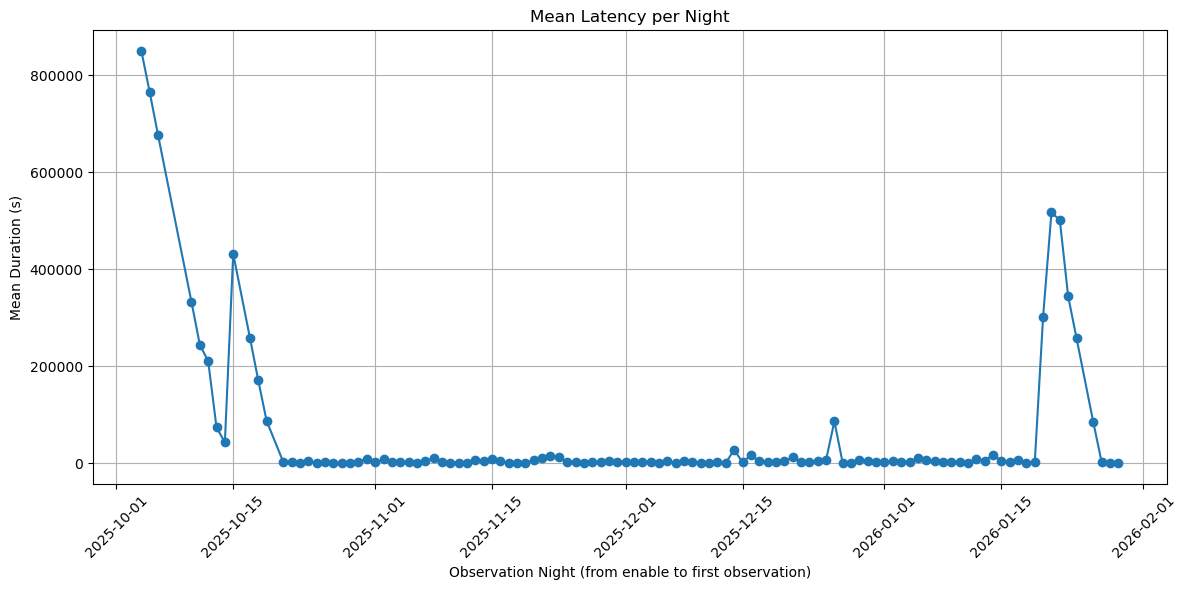

In [52]:
mean_by_night_cam['date'] = pd.to_datetime(mean_by_night_cam['date'])

plt.figure(figsize=(12,6))
plt.plot(mean_by_night_cam['date'], mean_by_night_cam['latency_camara'], marker='o')
plt.xlabel('Observation Night (from enable to first observation)')
plt.ylabel('Mean Duration (s)')
plt.title('Mean Latency per Night')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the results, I am not sure if too much data was collected in October, if the cross-referencing of the scripts I am doing here is completely wrong, or what is happening. The cross-referencing between the script and the observation is done by searching for the first observation closest to the script, but it is possible that these scripts were canceled and not observed, and these initial results do not make any sense. 

Change to minutes

In [53]:
mean_by_night_cam["latency_camara_min"] = (
    mean_by_night_cam["latency_camara"] / 60.0
)

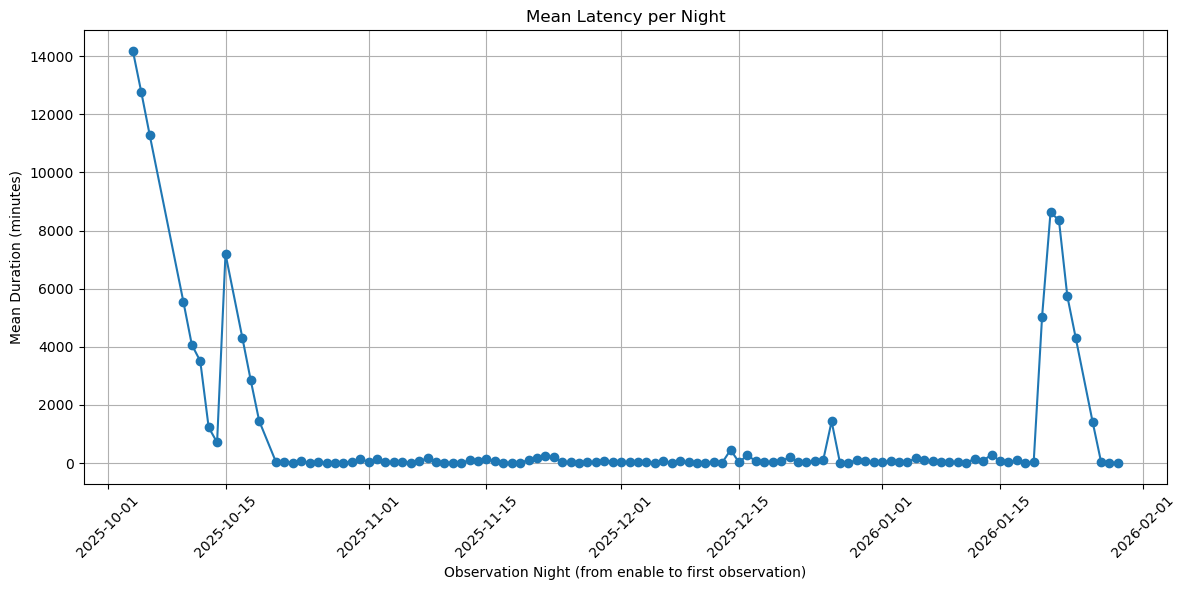

In [54]:
mean_by_night_cam["date"] = pd.to_datetime(mean_by_night_cam["date"])

plt.figure(figsize=(12, 6))
plt.plot(
    mean_by_night_cam["date"],
    mean_by_night_cam["latency_camara_min"],
    marker="o"
)

plt.xlabel("Observation Night (from enable to first observation)")
plt.ylabel("Mean Duration (minutes)")
plt.title("Mean Latency per Night")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Zoom

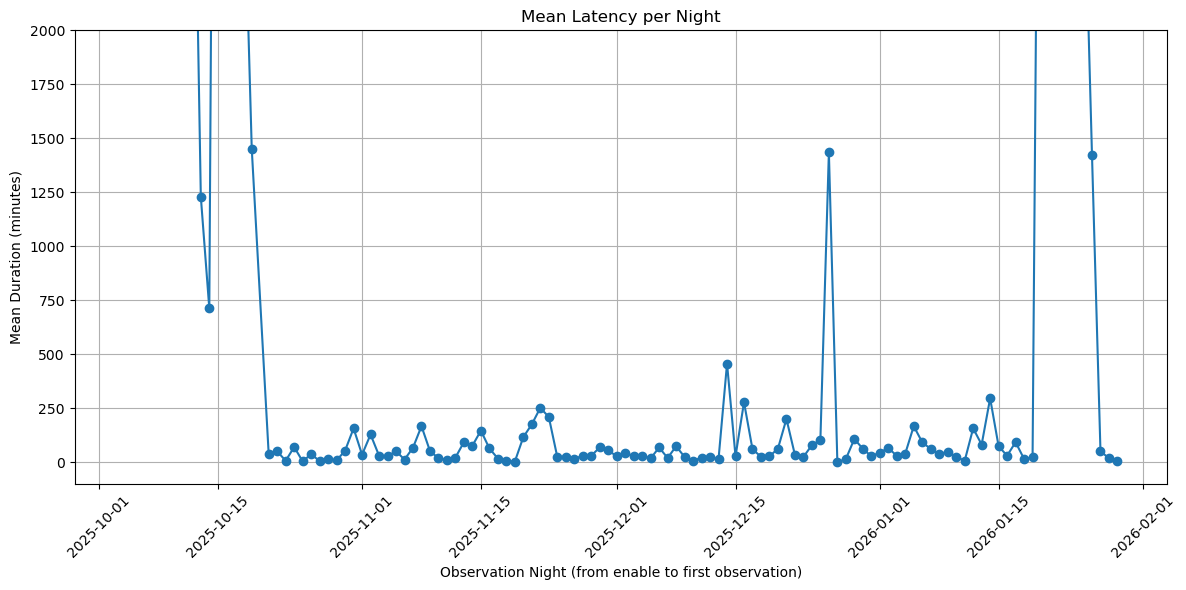

In [55]:
mean_by_night_cam["date"] = pd.to_datetime(mean_by_night_cam["date"])

plt.figure(figsize=(12, 6))
plt.plot(
    mean_by_night_cam["date"],
    mean_by_night_cam["latency_camara_min"],
    marker="o"
)

plt.xlabel("Observation Night (from enable to first observation)")
plt.ylabel("Mean Duration (minutes)")
plt.title("Mean Latency per Night")
plt.grid(True)
plt.xticks(rotation=45)

plt.ylim(-100, 2000)

plt.tight_layout()
plt.show()


## histogram

In [57]:
df_latencies["latency_camara_min"] = df_latencies["latency_camara"] / 60.0

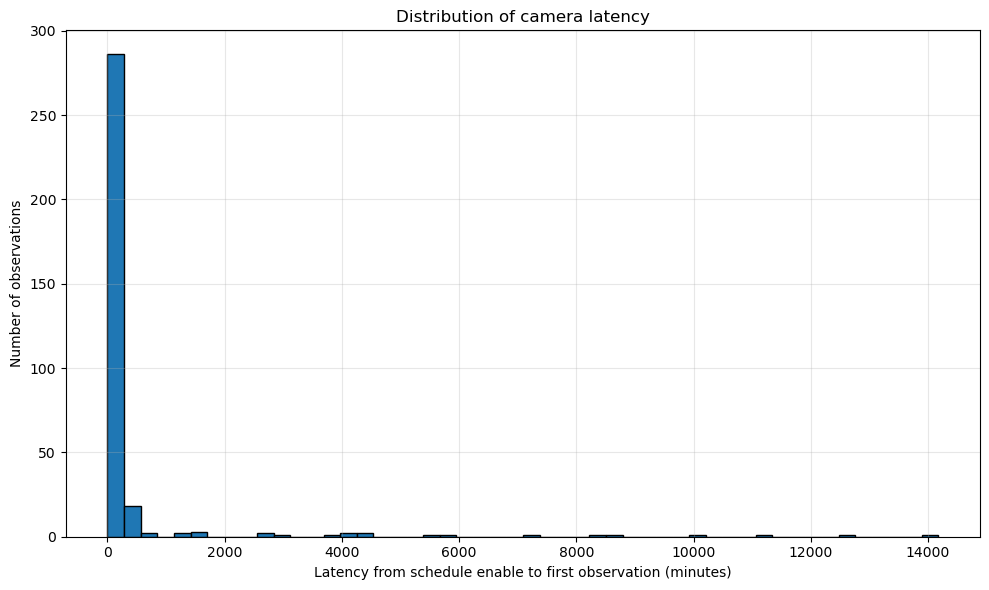

In [58]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_latencies["latency_camara_min"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Latency from schedule enable to first observation (minutes)")
plt.ylabel("Number of observations")
plt.title("Distribution of camera latency")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


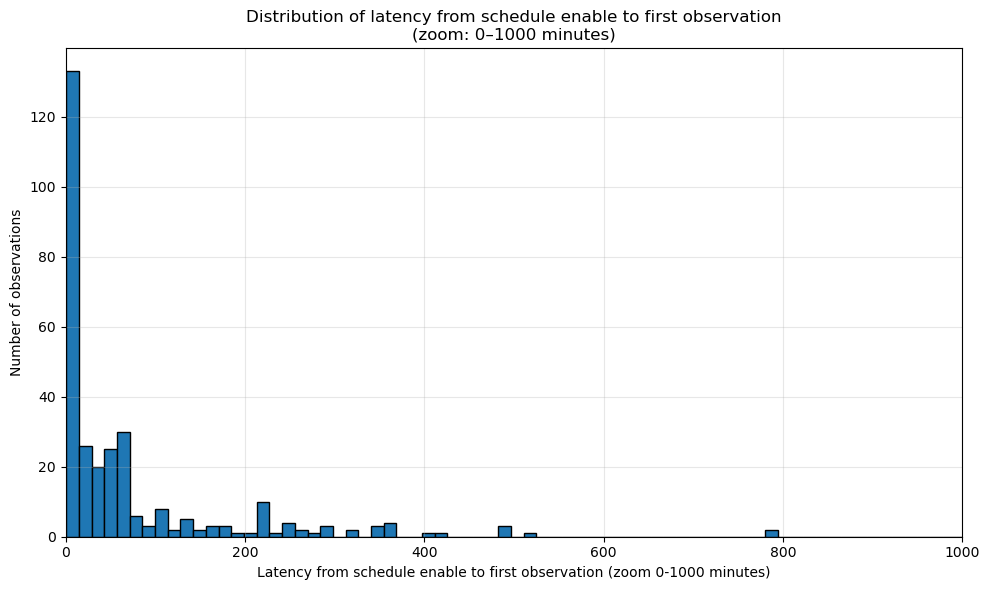

In [59]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_latencies["latency_camara_min"],
    bins=1000,
    edgecolor="black"
)

plt.xlim(0, 1000)

plt.xlabel("Latency from schedule enable to first observation (zoom 0-1000 minutes)")
plt.ylabel("Number of observations")
plt.title(
    "Distribution of latency from schedule enable to first observation\n"
    "(zoom: 0–1000 minutes)"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

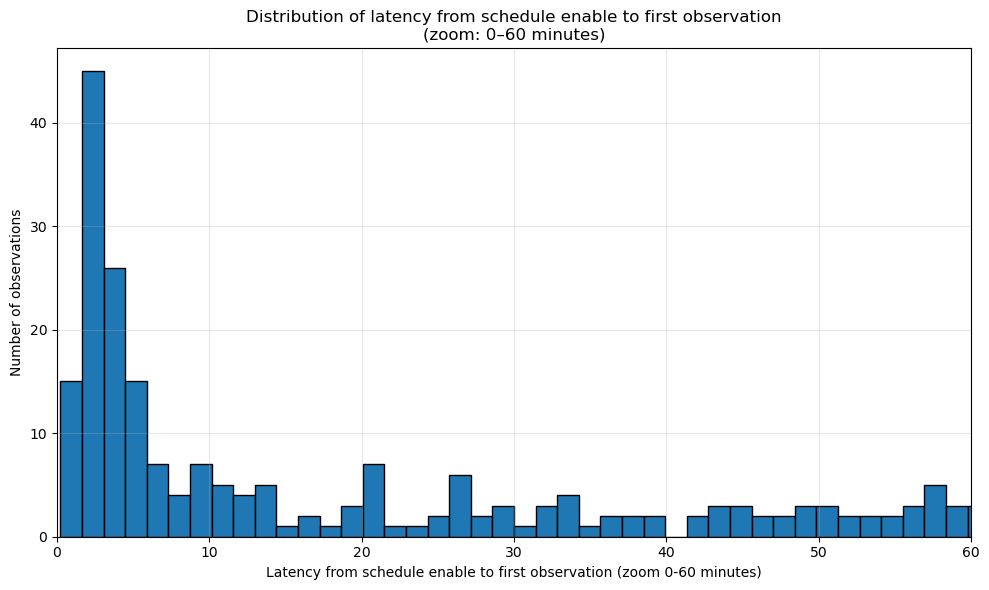

In [60]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_latencies["latency_camara_min"],
    bins=10000,
    edgecolor="black"
)

plt.xlim(0, 60)

plt.xlabel("Latency from schedule enable to first observation (zoom 0-60 minutes)")
plt.ylabel("Number of observations")
plt.title(
    "Distribution of latency from schedule enable to first observation\n"
    "(zoom: 0–60 minutes)"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()